# Preparation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import Isomap
from matplotlib.patches import Patch
from sklearn.decomposition import PCA
from sklearn.decomposition import SparsePCA

In [2]:
ge_matched = pd.read_csv(r"C:\Users\Juli\Documents\Master\Projekt Genomforschung\projekt_genomforschung\GeAndCancertype.csv", index_col=0)

In [7]:
ge_matched.head()

,SequencingID,ModelID,TSPAN6 (7105),SCYL3 (57147),BAD (572),LAP3 (51056),SNX11 (29916),CASP10 (843),CFLAR (8837),FKBP4 (2288),...,CHMP4A (29082),POLG2 (11232),RBM15B (29890),MRPL12 (6182),IKBKE (9641),DUSP14 (11072),PIP4K2B (8396),SANGER_MODEL_ID,CANCER_TYPE,META_CANCERTYPE
0,CDS-010xbm,ACH-001113,4.956577,3.179411,5.585888,4.856592,4.772382,2.296313,5.424482,6.670500,...,6.106993,5.376176,3.781716,5.136060,0.109694,5.508574,4.871706,SIDM01226,Unknown,Other
1,CDS-02TzJp,ACH-001289,4.954992,2.783576,6.156599,6.250399,4.671135,0.435660,4.823897,6.363479,...,6.519867,4.233543,4.201579,5.594133,0.785037,5.485163,4.834484,NaN,Unknown,Other
2,CDS-0693hw,ACH-001339,3.421952,2.615880,5.096717,6.269129,4.636549,1.269165,5.080769,5.556880,...,5.620372,3.471266,3.439807,6.475904,2.395142,5.904340,4.273322,SIDM00514,Unknown,Other
3,CDS-07Plat,ACH-001619,5.196729,2.144996,5.558329,4.844245,3.838508,2.290548,5.059550,5.065870,...,5.518346,3.973556,3.831816,7.464897,2.988021,5.422105,4.581984,NaN,Unknown,Other
4,CDS-08FOcu,ACH-001979,4.651643,2.454515,5.053415,7.138825,4.414575,2.354303,4.990197,5.049112,...,6.384074,2.434762,3.957525,4.427103,2.109839,5.237908,4.540963,NaN,Unknown,Other


In [4]:
category_map = {
    # Hematologic (Blood & Lymph)
    'T-Lymphoblastic Leukemia': 'Blood/Lymph',
    'Acute Myeloid Leukemia': 'Blood/Lymph',
    'Chronic Myelogenous Leukemia': 'Blood/Lymph',
    'B-Lymphoblastic Leukemia': 'Blood/Lymph',
    'Plasma Cell Myeloma': 'Blood/Lymph',
    "T-Cell Non-Hodgkin's Lymphoma": 'Blood/Lymph',
    "B-Cell Non-Hodgkin's Lymphoma": 'Blood/Lymph',
    "Burkitt's Lymphoma": 'Blood/Lymph',
    "Hodgkin's Lymphoma": 'Blood/Lymph',
    'Other Blood Cancers': 'Blood/Lymph',

    # Gastrointestinal (GI Tract)
    'Colorectal Carcinoma': 'Gastrointestinal',
    'Gastric Carcinoma': 'Gastrointestinal',
    'Pancreatic Carcinoma': 'Gastrointestinal',
    'Hepatocellular Carcinoma': 'Gastrointestinal',
    'Biliary Tract Carcinoma': 'Gastrointestinal',
    'Esophageal Carcinoma': 'Gastrointestinal',
    'Esophageal Squamous Cell Carcinoma': 'Gastrointestinal',

    # Thoracic (Lung & Chest)
    'Non-Small Cell Lung Carcinoma': 'Thoracic',
    'Squamous Cell Lung Carcinoma': 'Thoracic',
    'Small Cell Lung Carcinoma': 'Thoracic',
    'Mesothelioma': 'Thoracic',

    # Sarcomas (Bone & Soft Tissue)
    "Ewing's Sarcoma": 'Sarcoma/Bone',
    'Osteosarcoma': 'Sarcoma/Bone',
    'Chondrosarcoma': 'Sarcoma/Bone',
    'Rhabdomyosarcoma': 'Sarcoma/Bone',
    'Other Sarcomas': 'Sarcoma/Bone',

    # CNS (Brain)
    'Glioblastoma': 'CNS',
    'Glioma': 'CNS',
    'Neuroblastoma': 'CNS', # Oft PNS, aber meist mit ZNS gruppiert

    # Gynecologic / Urologic
    'Ovarian Carcinoma': 'Uro/Gyn',
    'Cervical Carcinoma': 'Uro/Gyn',
    'Endometrial Carcinoma': 'Uro/Gyn',
    'Breast Carcinoma': 'Uro/Gyn',
    'Prostate Carcinoma': 'Uro/Gyn',
    'Bladder Carcinoma': 'Uro/Gyn',
    'Kidney Carcinoma': 'Uro/Gyn',

    # Head & Neck / Skin / Endocrine
    'Melanoma': 'Skin/HNSC',
    'Head and Neck Carcinoma': 'Skin/HNSC',
    'Oral Cavity Carcinoma': 'Skin/HNSC',
    'Thyroid Gland Carcinoma': 'Skin/HNSC',

    # Others
    'Non-Cancerous': 'Control',
    'Other Solid Cancers': 'Other'
}
# Anwendung auf den DataFrame
#df['META_CANCERTYPE'] = df['CANCER_TYPE'].map(category_map).fillna('Other')
ge_matched['META_CANCERTYPE'] = ge_matched['CANCER_TYPE'].map(category_map).fillna('Other')

Generate a personalized color palette


In [8]:
# get unique categories for color mapping
unique_categories = sorted(ge_matched['META_CANCERTYPE'].unique())

# generate a color palette with as many colors as unique categories
base_colors = sns.color_palette("Set1", len(unique_categories))
color_dict = dict(zip(unique_categories, base_colors))

# color coding for "Other" and "Control"
if 'Other' in color_dict:
    color_dict['Other'] = '#d3d3d3'

if 'Control' in color_dict:
    color_dict['Control'] = '#7f7f7f'

# Visualize the relationship between gene expression and drug response


## t-SNE


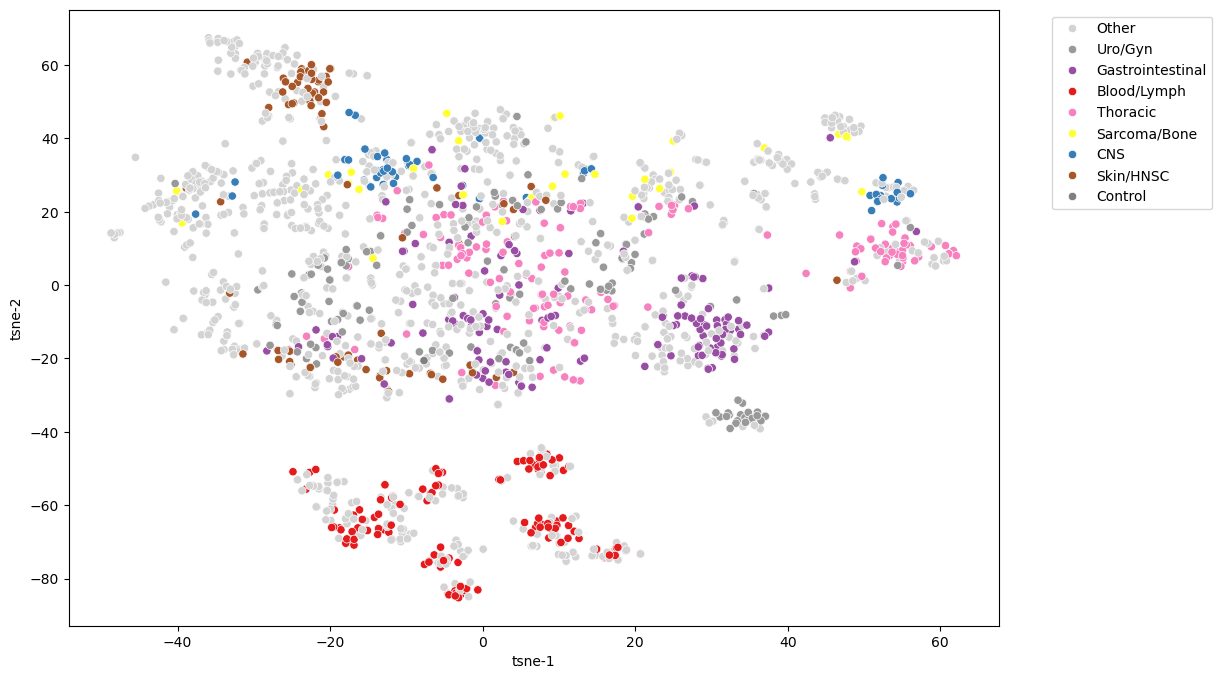

In [9]:
# selection of features for t-SNE (only gene columns)
#gene_features = master_df.drop_duplicates(subset=['ModelID']).filter(regex='\(.*\)')
gene_features = ge_matched.iloc[: , 2:980]

# treat missing values (t-SNE does not allow NaNs)
gene_features = gene_features.fillna(gene_features.mean())

# standardize the data (mean=0, variance=1)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(gene_features)

# perplexity is important hyperparameter (usually between 5 and 50)
tsne = TSNE(n_components=2, perplexity=15, init='pca', learning_rate='auto')
tsne_results = tsne.fit_transform(scaled_data)
# write the t-SNE results back into the DataFrame for plotting
clean_df = gene_features.dropna(subset=gene_features.columns).copy()
clean_df['tsne-1'] = tsne_results[:, 0]
clean_df['tsne-2'] = tsne_results[:, 1]
clean_df['META_CANCERTYPE'] = ge_matched['META_CANCERTYPE'].values

# plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x="tsne-1", y="tsne-2",
    hue="META_CANCERTYPE",
    palette=color_dict,
    data=clean_df,
    legend="full")

plt.title('')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## IsoMap testing


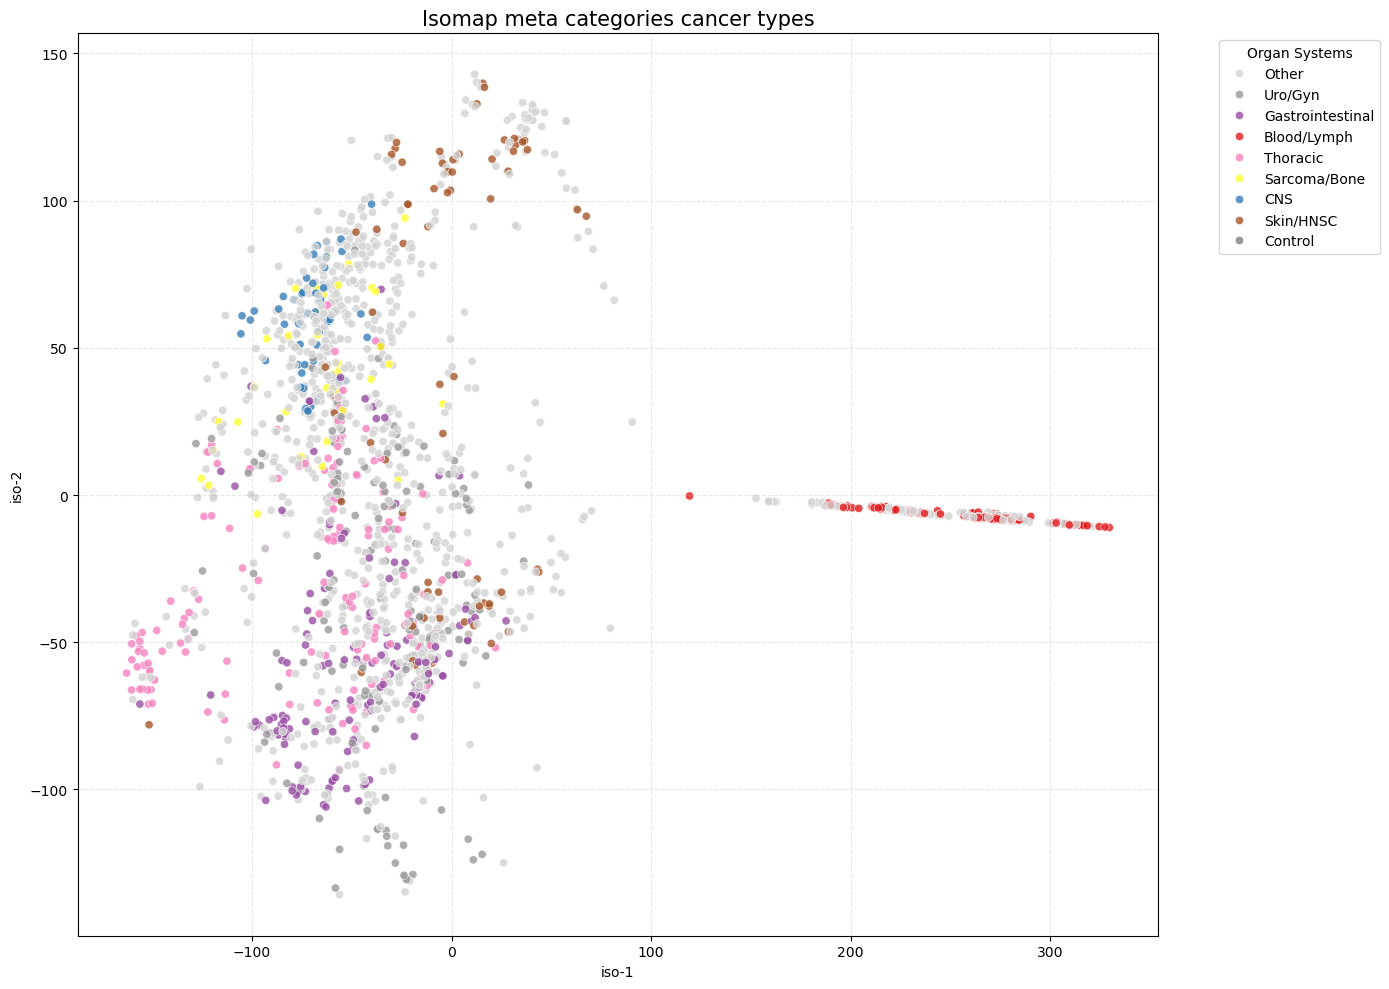

In [10]:
embedding = Isomap(n_components=2,  n_neighbors=10)
X_transformed = embedding.fit_transform(ge_matched.iloc[: , 2:980])  # assuming the first two columns are non-gene features
iso_df = pd.DataFrame(X_transformed, columns=['iso-1', 'iso-2'])
iso_df['META_CANCERTYPE'] = ge_matched['META_CANCERTYPE'].values
plt.figure(figsize=(14, 10))
sns.scatterplot(
    x='iso-1', y='iso-2', 
    hue='META_CANCERTYPE', 
    data=iso_df, 
    palette=color_dict, # personalized color dictionary
    alpha=0.8,
    edgecolor='w',
    linewidth=0.5
)

# legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Organ Systems')
plt.title("Isomap meta categories cancer types", fontsize=15)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()
ge_filtered = ge_matched[ge_matched['META_CANCERTYPE'] != 'Other'].copy()

c:\Users\Juli\anaconda3\Lib\site-packages\sklearn\manifold\_isomap.py:384: UserWarning:

The number of connected components of the neighbors graph is 3 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.

c:\Users\Juli\anaconda3\Lib\site-packages\scipy\sparse\_index.py:108: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.

c:\Users\Juli\anaconda3\Lib\site-packages\scipy\sparse\_index.py:108: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.

c:\Users\Juli\anaconda3\Lib\site-packages\scipy\sparse\_index.py:108: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.



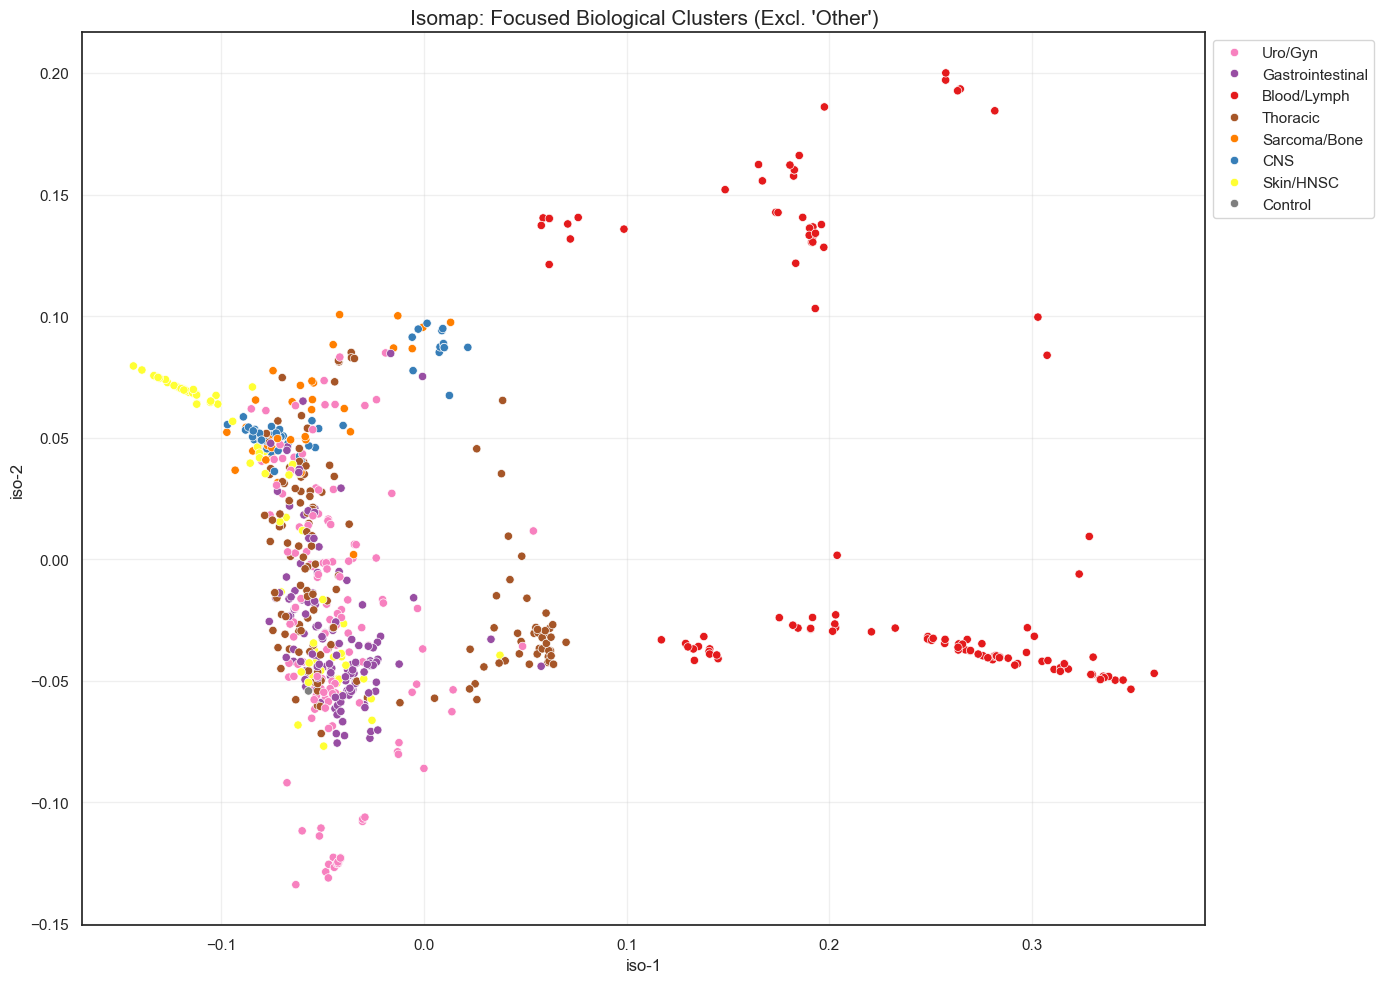

In [25]:

embedding = Isomap(n_neighbors=5, metric='cosine')
X_transformed_filtered = embedding.fit_transform(ge_filtered.iloc[: , 2:980])
iso_df_filtered = pd.DataFrame(X_transformed_filtered, columns=['iso-1', 'iso-2'])
iso_df_filtered['META_CANCERTYPE'] = ge_filtered['META_CANCERTYPE'].values

# Update the color dictionary (excluding ‘Other’)
unique_categories_filtered = sorted(iso_df_filtered['META_CANCERTYPE'].unique())
colors_filtered = sns.color_palette("Set1", len(unique_categories_filtered))
color_dict_filtered = dict(zip(unique_categories_filtered, colors_filtered))
if 'Control' in color_dict_filtered:
    color_dict_filtered['Control'] = '#7f7f7f'

plt.figure(figsize=(14, 10))
sns.scatterplot(x='iso-1', y='iso-2', hue='META_CANCERTYPE',
                data=iso_df_filtered, palette=color_dict_filtered)
plt.title("Isomap: Focused Biological Clusters (Excl. 'Other')", fontsize=15)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()


## PCA


Irgendwie ist die normale PCA nicht so das wahre, also probiere ich nochmal SparsePCA und KernelPCA

SparsePCA: can produce a principal component that involves only a few genes, so researchers can focus on these specific genes for further analysis

KernelPCA: ??

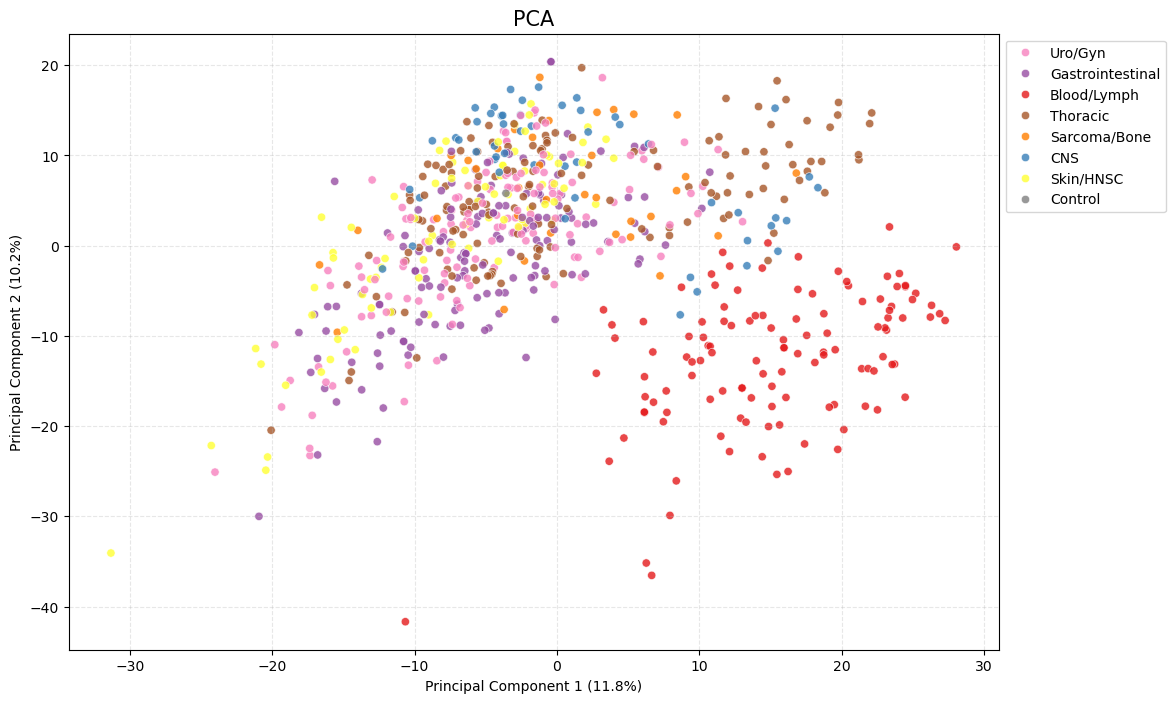

In [14]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(ge_filtered.iloc[: , 2:980])

pca = PCA(n_components=5)
pca_results = pca.fit_transform(scaled_data)

pca_plot_df = pd.DataFrame(data=pca_results, 
                           columns=['PC1', 'PC2', 'PCA3', 'PCA4', 'PCA5'])
pca_plot_df['META_CANCERTYPE'] = ge_filtered['META_CANCERTYPE'].values

exp_var = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='META_CANCERTYPE', 
    data=pca_plot_df,
    palette=color_dict_filtered,
    alpha=0.8,
    edgecolor='w'
)

plt.title(f"PCA", fontsize=15)
plt.xlabel(f"Principal Component 1 ({exp_var[0]:.1f}%)")
plt.ylabel(f"Principal Component 2 ({exp_var[1]:.1f}%)")
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

## UMAP

In [3]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
sns.set(style='white', context='notebook', rc={'figure.figsize':(14,10)})

### 2-dimensional

In [5]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean')
scaled_data = StandardScaler().fit_transform(ge_matched.iloc[: , 2:980])

In [6]:
embedding = reducer.fit_transform(scaled_data)
embedding.shape

(1754, 2)

In [15]:
pca_plot_df = pd.DataFrame()

pca_plot_df['umap-1'] = embedding[:, 0]
pca_plot_df['umap-2'] = embedding[:, 1]

pca_plot_df['META_CANCERTYPE'] = ge_matched['META_CANCERTYPE'].values

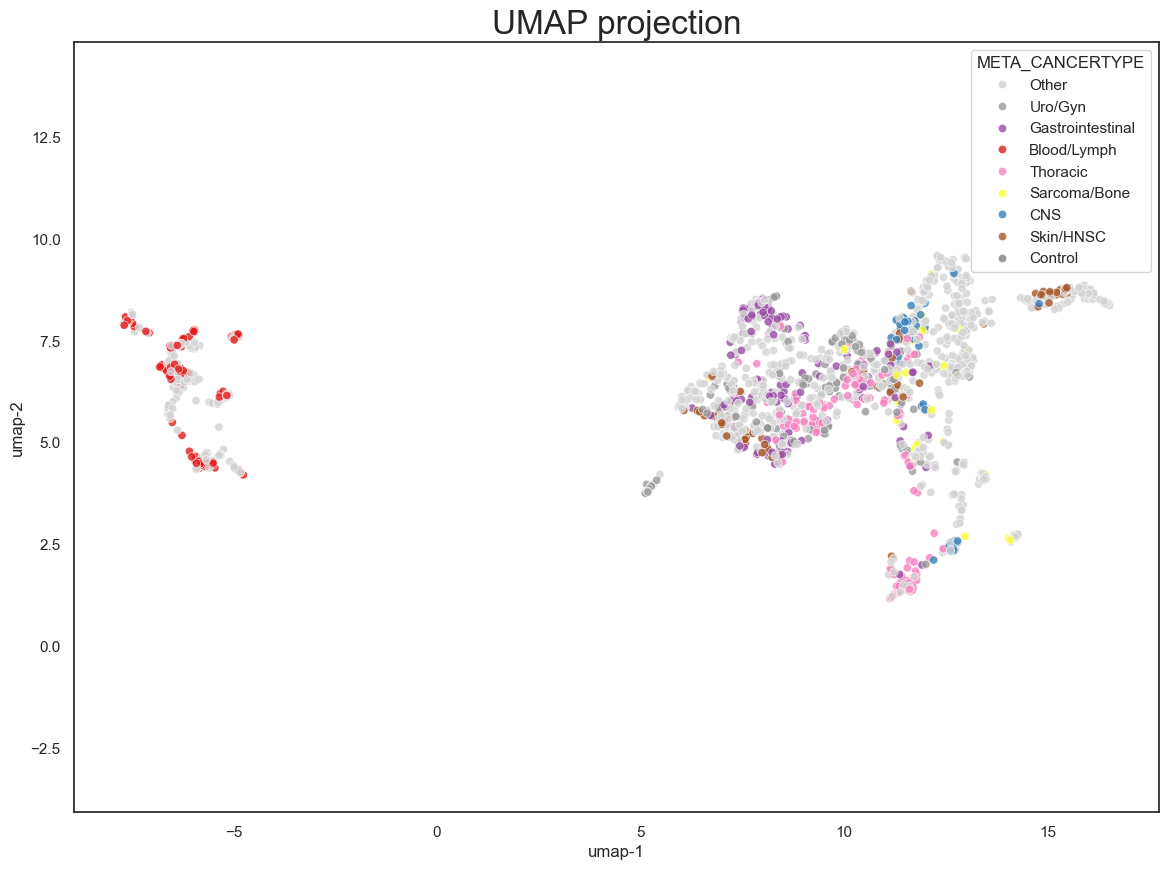

In [17]:
sns.scatterplot(
    x='umap-1', y='umap-2', 
    hue='META_CANCERTYPE', 
    data=pca_plot_df,
    palette=color_dict,
    alpha=0.8,
    edgecolor='w'
) 

plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection', fontsize=24);

### 3-dimensional

In [18]:
reducer = umap.UMAP(n_components=3)
embedding_3d = reducer.fit_transform(scaled_data)
embedding_3d.shape

(1754, 3)

In [19]:
import plotly.express as px

In [22]:
fig = px.scatter_3d(
    x=embedding_3d[:, 0],
    y=embedding_3d[:, 1],
    z=embedding_3d[:, 2],
    color=ge_matched['META_CANCERTYPE'],
    title='UMAP 3D Projection',
    labels={'color': 'Cancer Type'},
    opacity=0.8
)
fig.update_traces(marker=dict(size=3))
fig.show()

## Clustering for identifying co-sensitive cell lines and structurally related drug groups

First clustering heatmap with gene expression data and cancer types

Pick genes with the biggest variance: $$ \sigma^2 = \frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2 $$

c:\Users\Juli\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.

c:\Users\Juli\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.



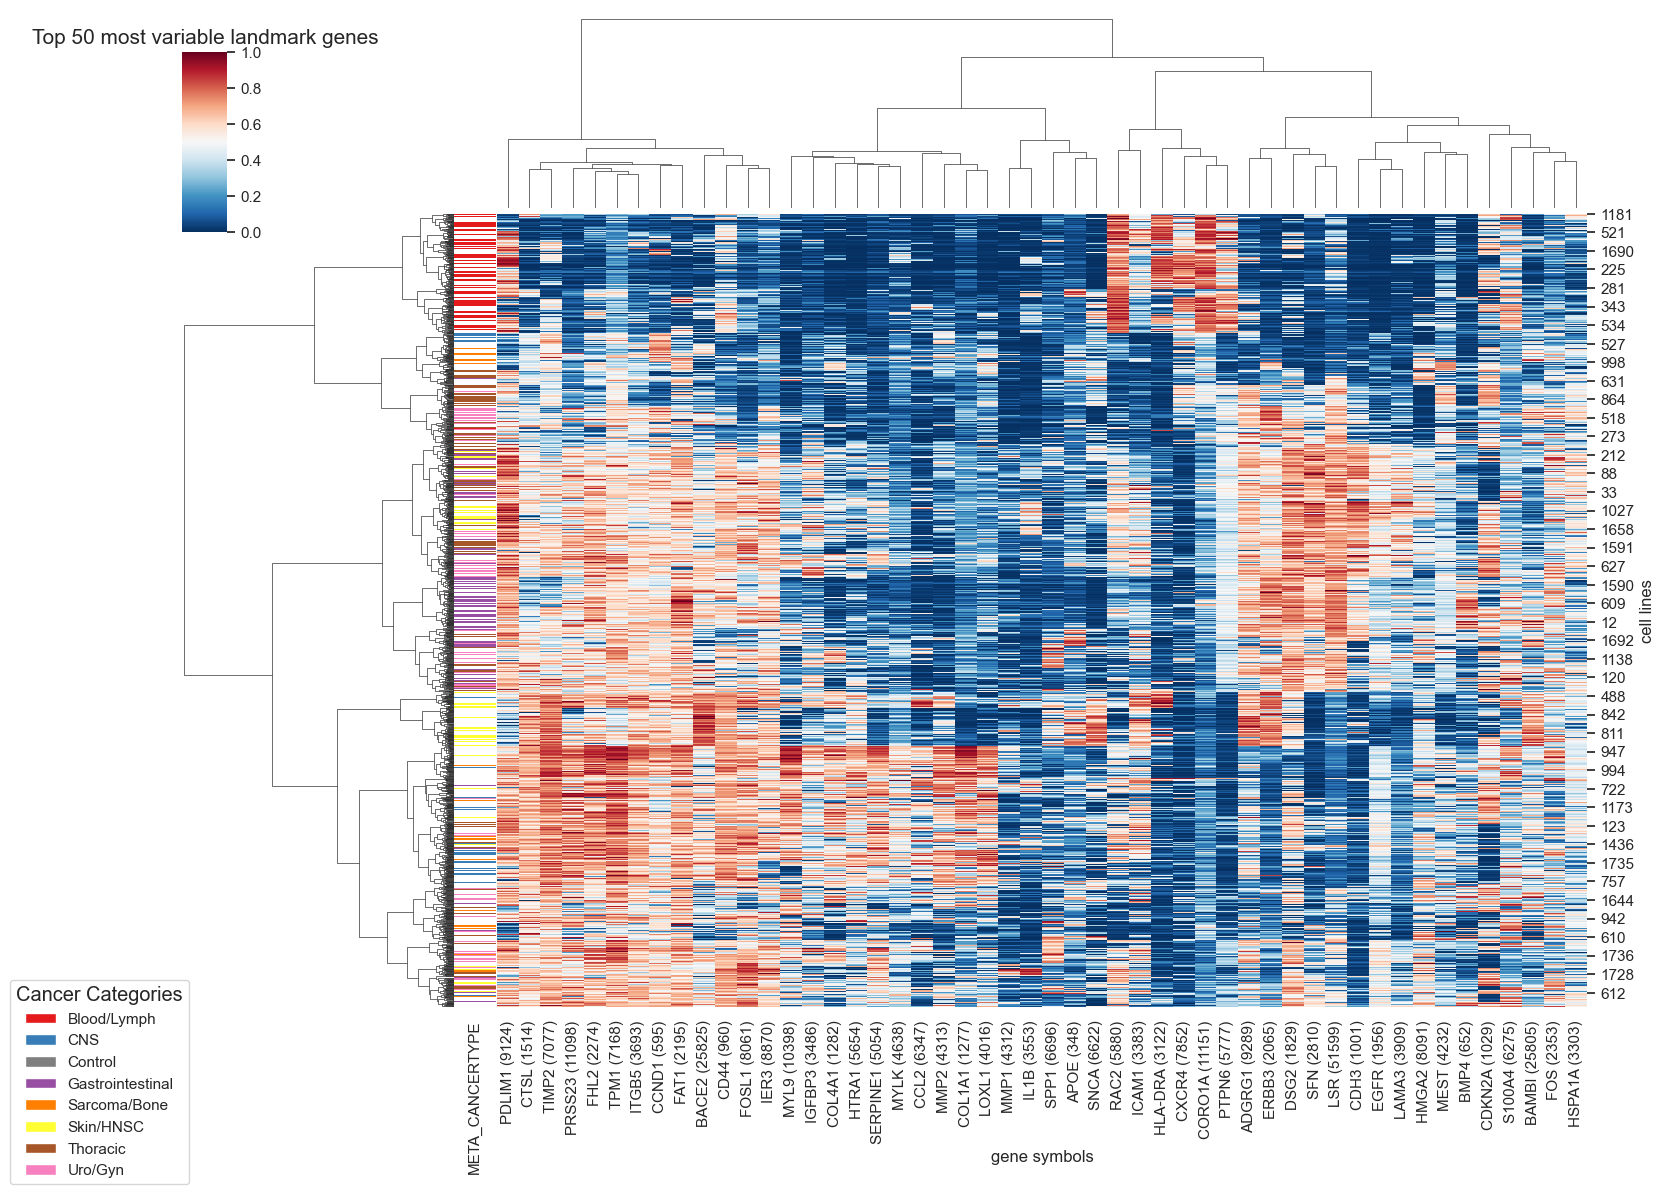

In [27]:
log_data = ge_matched.iloc[:, 2:980]  # assuming the first two columns are non-gene features
top_variance_genes = log_data.var().sort_values(ascending=False).head(50).index
heatmap_data = log_data[top_variance_genes]
ge_filtered = ge_matched[ge_matched['META_CANCERTYPE'] != 'Other'].copy()
row_colors = ge_filtered['META_CANCERTYPE'].map(color_dict_filtered)

# clustermap
cg = sns.clustermap(
    heatmap_data, 
    metric="euclidean", 
    method="ward", # complete looks okay aswell, but ward is more common for gene expression data
    cmap="RdBu_r", # red for upregulated, blue for downregulated
    standard_scale=1, # scales genes to 0-1, making patterns easier to see
    row_colors=row_colors,
    figsize=(15, 12),
    cbar_pos=(0.02, 0.8, 0.03, 0.15))

cg.ax_heatmap.set_xlabel("gene symbols", fontsize=12)
cg.ax_heatmap.set_ylabel("cell lines", fontsize=12)
plt.title("Top 50 most variable landmark genes", fontsize=15)
legend_elements = [Patch(facecolor=color_dict_filtered[cat], label=cat) for cat in color_dict_filtered]
plt.legend(handles=legend_elements, title='Cancer Categories', 
           bbox_to_anchor=(-0.1,0), bbox_transform=plt.gcf().transFigure, loc='lower left',
           title_fontsize='large')
plt.show()

Now I try to find cell lines that react similar to specific drugs.

In [3]:
master_df = pd.read_csv(r"C:\Users\Juli\Documents\Master\Projekt Genomforschung\harmonised_data.csv")

In [4]:
master_df.head()

,SequencingID,ModelID,TSPAN6 (7105),SCYL3 (57147),BAD (572),LAP3 (51056),SNX11 (29916),CASP10 (843),CFLAR (8837),FKBP4 (2288),...,CANCER_TYPE,DRUG_ID,DRUG_NAME,LN_IC50,Z_SCORE,RMSE,AUC,SMILES,MorganFP,PharmacophoreFeatures
0,CDS-0CqPRM,ACH-000242,7.10594,2.700053,5.803904,5.66261,4.231824,2.283468,4.735717,6.484923,...,Bladder Carcinoma,1003,Camptothecin,-2.963191,-0.383200,0.094466,0.821438,CCC1(C2=C(COC1=O)C(=O)N3CC4=CC5=CC=CC=C5N=C4C3...,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,"{'Donor': 1, 'Acceptor': 5, 'Aromatic': 3, 'Hy..."
1,CDS-0CqPRM,ACH-000242,7.10594,2.700053,5.803904,5.66261,4.231824,2.283468,4.735717,6.484923,...,Bladder Carcinoma,1004,Vinblastine,-4.023106,-0.244142,0.122361,0.712813,CCC1(CC2CC(C3=C(CCN(C2)C1)C4=CC=CC=C4N3)(C5=C(...,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,"{'Donor': 5, 'Acceptor': 9, 'PosIonizable': 2,..."
2,CDS-0CqPRM,ACH-000242,7.10594,2.700053,5.803904,5.66261,4.231824,2.283468,4.735717,6.484923,...,Bladder Carcinoma,1005,Cisplatin,2.848175,-0.203192,0.108946,0.938878,N.N.Cl[Pt]Cl,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,{'Donor': 2}
3,CDS-0CqPRM,ACH-000242,7.10594,2.700053,5.803904,5.66261,4.231824,2.283468,4.735717,6.484923,...,Bladder Carcinoma,1006,Cytarabine,2.218343,0.292158,0.117640,0.953169,C1=CN(C(=O)N=C1N)C2C(C(C(O2)CO)O)O,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,"{'Donor': 4, 'Acceptor': 6, 'Aromatic': 1}"
4,CDS-0CqPRM,ACH-000242,7.10594,2.700053,5.803904,5.66261,4.231824,2.283468,4.735717,6.484923,...,Bladder Carcinoma,1007,Docetaxel,-4.240700,0.074531,0.070175,0.884847,CC1=C2C(C(=O)C3(C(CC4C(C3C(C(C2(C)C)(CC1OC(=O)...,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,"{'Donor': 5, 'Acceptor': 14, 'Aromatic': 2, 'H..."


Versuch, zu clustern:

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the Drug-Response Matrix
# Rows = Cell Lines (SANGER_MODEL_ID)
# Columns = Drug Names
# Values = Sensitivity (LN_IC50)
pivot_df = master_df.pivot_table(
    index='SANGER_MODEL_ID', 
    columns='DRUG_NAME', 
    values='LN_IC50'
)

# 2. Handling Missing Values (Crucial for Clustering)
# Most clustering algorithms cannot handle NaNs. 
# We fill them with the mean of that specific drug.
pivot_df_filled = pivot_df.apply(lambda x: x.fillna(x.mean()), axis=0)

# 3. Optional: Add Cancer Type as a label for later
# We create a mapping from the original dataframe
id_to_cancer = master_df[['SANGER_MODEL_ID', 'CANCER_TYPE']].drop_duplicates().set_index('SANGER_MODEL_ID')

print(f"Pivot Matrix Shape: {pivot_df_filled.shape}")

Pivot Matrix Shape: (715, 286)


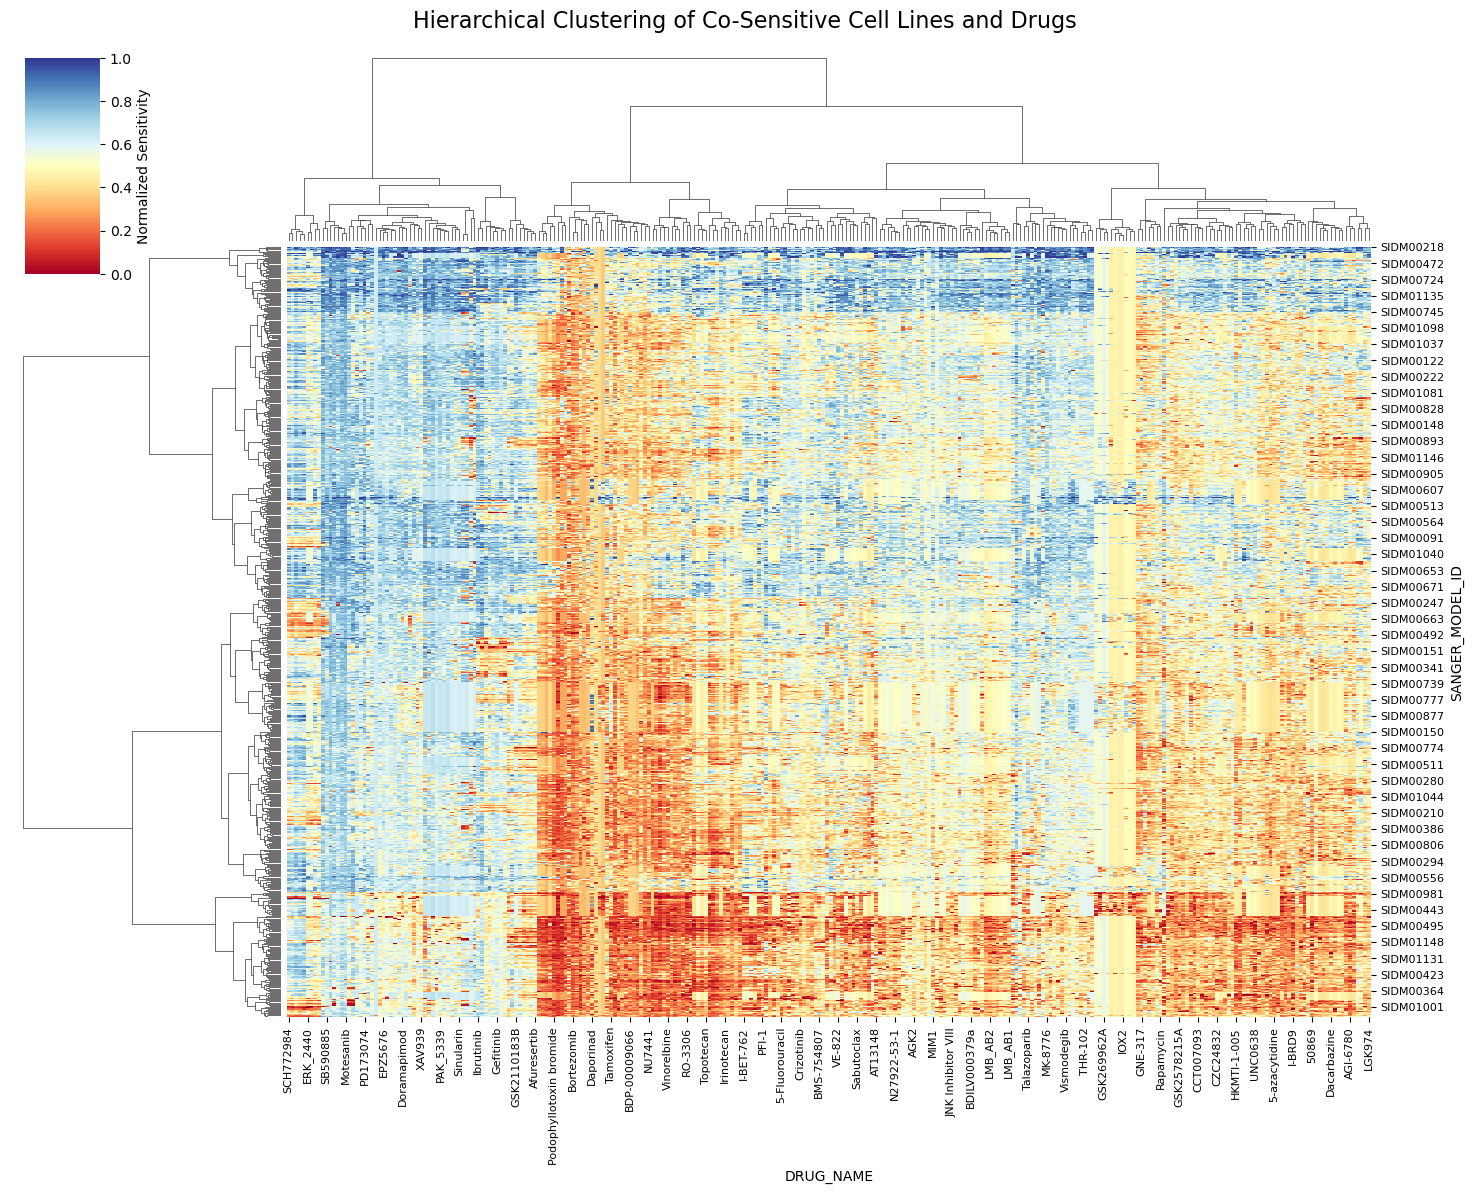

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# perform Hierarchical Clustering
# metric='euclidean': calculates the straight-line distance between profiles
# method='ward': minimizes the variance within clusters (very common for biological data)
# standard_scale=1: normalizes columns (drugs) so values are between 0 and 1
g = sns.clustermap(
    pivot_df_filled, 
    metric='euclidean', 
    method='ward', 
    cmap='RdYlBu', # Blue = Resistant, Red = Sensitive
    standard_scale=1, 
    figsize=(15, 12),
    cbar_kws={'label': 'Normalized Sensitivity'}
)

g.fig.suptitle('Hierarchical Clustering of Co-Sensitive Cell Lines and Drugs', y=1.02, fontsize=16)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=8) # Rotate drug names for readability
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)

plt.show()

0 as minimum value for that drug (the most sensitive/lowest IC50​), 1 as maximum value for that drug (the most resistant/highest IC50​).